In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ratings = pd.read_csv(
    "../data/ratings.dat",
    sep="::",
    engine="python",
    names=["userId", "movieId", "rating", "timestamp"]
)

ratings.head()

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [4]:
ratings.shape

(1000209, 4)

In [5]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   userId     1000209 non-null  int64
 1   movieId    1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


In [6]:
ratings.describe()

,userId,movieId,rating,timestamp
count,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06
mean,3.024512e+03,1.865540e+03,3.581564e+00,9.722437e+08
std,1.728413e+03,1.096041e+03,1.117102e+00,1.215256e+07
min,1.000000e+00,1.000000e+00,1.000000e+00,9.567039e+08
25%,1.506000e+03,1.030000e+03,3.000000e+00,9.653026e+08
50%,3.070000e+03,1.835000e+03,4.000000e+00,9.730180e+08
75%,4.476000e+03,2.770000e+03,4.000000e+00,9.752209e+08
max,6.040000e+03,3.952000e+03,5.000000e+00,1.046455e+09


In [7]:
movies = pd.read_csv(
    "../data/movies.dat",
    sep="::",
    engine="python",
    names=["movieId", "title", "genres"],
    encoding="latin-1"
)

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
data = ratings.merge(
    movies,
    on="movieId",
    how="left"
)

data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [9]:
ratings["rating"].value_counts().sort_index()

rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64

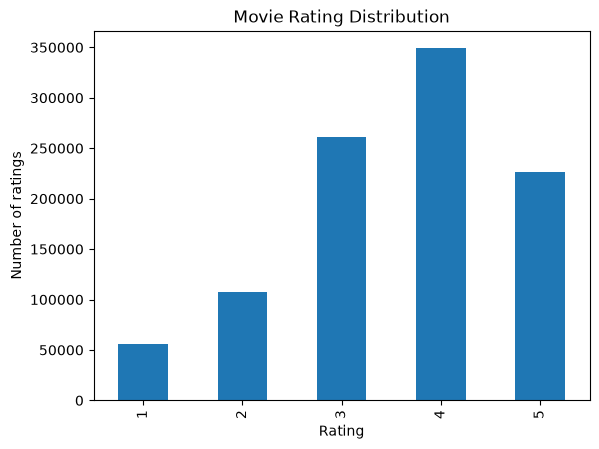

In [10]:
ratings["rating"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Number of ratings")
plt.title("Movie Rating Distribution")
plt.show()

In [11]:
data["positive"] = (data["rating"] >= 4).astype(int)

In [12]:
data["positive"].value_counts()

positive
1    575281
0    424928
Name: count, dtype: int64

In [13]:
user_history = (
    data
    .sort_values(["userId", "timestamp"])
    .groupby("userId")
    .agg({
        "movieId": list,
        "rating": list
    })
)

In [14]:
user_history.head()

,movieId,rating
userId,,
1,"[3186, 1270, 1721, 1022, 2340, 1836, 3408, 280...","[4, 5, 4, 5, 3, 5, 4, 5, 4, 5, 3, 4, 4, 4, 4, ..."
2,"[1198, 1210, 1217, 2717, 1293, 2943, 1225, 119...","[4, 4, 3, 3, 5, 4, 5, 5, 5, 4, 4, 2, 5, 4, 5, ..."
3,"[593, 2858, 3534, 1968, 1431, 1961, 1266, 1378...","[3, 4, 3, 4, 3, 4, 5, 5, 4, 5, 4, 5, 4, 4, 5, ..."
4,"[1210, 1097, 3468, 480, 3527, 260, 1196, 1198,...","[3, 4, 5, 4, 1, 5, 2, 5, 5, 5, 4, 5, 5, 5, 4, ..."
5,"[2717, 908, 919, 1250, 356, 2858, 1127, 2188, ...","[1, 4, 4, 5, 1, 4, 1, 1, 3, 2, 5, 4, 5, 4, 3, ..."


In [15]:
movie_stats = (
    data.groupby("movieId")
    .agg(
        rating_count=("rating", "count"),
        rating_mean=("rating", "mean")
    )
    .reset_index()
)

In [16]:
movie_stats = movie_stats.merge(
    movies,
    on="movieId",
    how="left"
)

In [17]:
popular_movies = movie_stats.sort_values(
    ["rating_count", "rating_mean"],
    ascending=False
)

In [18]:
popular_movies[
    ["movieId", "title", "rating_count", "rating_mean"]
].head(20)

,movieId,title,rating_count,rating_mean
2651,2858,American Beauty (1999),3428,4.317386
253,260,Star Wars: Episode IV - A New Hope (1977),2991,4.453694
1106,1196,Star Wars: Episode V - The Empire Strikes Back...,2990,4.292977
1120,1210,Star Wars: Episode VI - Return of the Jedi (1983),2883,4.022893
466,480,Jurassic Park (1993),2672,3.763847
1848,2028,Saving Private Ryan (1998),2653,4.337354
575,589,Terminator 2: Judgment Day (1991),2649,4.058513
2374,2571,"Matrix, The (1999)",2590,4.315830
1178,1270,Back to the Future (1985),2583,3.990321
579,593,"Silence of the Lambs, The (1991)",2578,4.351823


In [19]:
def recommend_popular(user_id, n=10):
    watched = set(
        data.loc[data["userId"] == user_id, "movieId"]
    )

    recommendations = popular_movies[
        ~popular_movies["movieId"].isin(watched)
    ]

    return recommendations.head(n)[
        ["movieId", "title", "rating_mean", "rating_count"]
    ]

In [20]:
recommend_popular(1, 10)

,movieId,title,rating_mean,rating_count
2651,2858,American Beauty (1999),4.317386,3428
1106,1196,Star Wars: Episode V - The Empire Strikes Back...,4.292977,2990
1120,1210,Star Wars: Episode VI - Return of the Jedi (1983),4.022893,2883
466,480,Jurassic Park (1993),3.763847,2672
575,589,Terminator 2: Judgment Day (1991),4.058513,2649
2374,2571,"Matrix, The (1999)",4.315830,2590
579,593,"Silence of the Lambs, The (1991)",4.351823,2578
1449,1580,Men in Black (1997),3.739953,2538
1108,1198,Raiders of the Lost Ark (1981),4.477725,2514
106,110,Braveheart (1995),4.234957,2443


In [21]:
movies[["movieId", "title", "genres"]].head(20)

,movieId,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children's
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [22]:
genre_dummies = movies["genres"].str.get_dummies(sep="|")

genre_dummies.head()

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [23]:
movie_features = pd.concat(
    [
        movies[["movieId", "title"]],
        genre_dummies
    ],
    axis=1
)

movie_features.head()

,movieId,title,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,5,Father of the Bride Part II (1995),0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [24]:
user_1 = data[data["userId"] == 1]

user_1[["title", "genres", "rating"]].sort_values(
    "rating",
    ascending=False
).head(20)

,title,genres,rating
0,One Flew Over the Cuckoo's Nest (1975),Drama,5
4,"Bug's Life, A (1998)",Animation|Children's|Comedy,5
10,Beauty and the Beast (1991),Animation|Children's|Musical,5
7,"Christmas Story, A (1983)",Comedy|Drama,5
6,Ben-Hur (1959),Action|Adventure|Drama,5
18,Awakenings (1990),Drama,5
14,"Sound of Music, The (1965)",Musical,5
40,Toy Story (1995),Animation|Children's|Comedy,5
41,Rain Man (1988),Drama,5
36,"Last Days of Disco, The (1998)",Drama,5


In [25]:
user_positive = user_1[user_1["rating"] >= 4]

user_positive_genres = (
    user_positive["genres"]
    .str.split("|")
    .explode()
    .value_counts()
)

user_positive_genres

genres
Drama         21
Children's    18
Animation     14
Musical       12
Comedy        11
Action         4
Adventure      4
Fantasy        3
Sci-Fi         3
Romance        3
War            2
Thriller       2
Crime          2
Name: count, dtype: int64

In [26]:
genre_preferences = (
    data[data["rating"] >= 4]
    .assign(genre=data["genres"].str.split("|"))
    .explode("genre")
    .groupby(["userId", "genre"])
    .size()
    .reset_index(name="preference_count")
)

In [27]:
genre_preferences[
    genre_preferences["userId"] == 1
].sort_values(
    "preference_count",
    ascending=False
)

,userId,genre,preference_count
6,1,Drama,21
3,1,Children's,18
2,1,Animation,14
8,1,Musical,12
4,1,Comedy,11
1,1,Adventure,4
0,1,Action,4
7,1,Fantasy,3
9,1,Romance,3
10,1,Sci-Fi,3


In [28]:
def recommend_personalized(user_id, n=10):

    # Movies already seen by the user
    watched = set(
        data.loc[
            data["userId"] == user_id,
            "movieId"
        ]
    )

    # User's preferred genres
    preferences = genre_preferences[
        genre_preferences["userId"] == user_id
    ]

    genre_scores = dict(
        zip(
            preferences["genre"],
            preferences["preference_count"]
        )
    )

    recommendations = movie_features[
        ~movie_features["movieId"].isin(watched)
    ].copy()

    # Calculate preference score
    recommendations["preference_score"] = 0

    for genre, score in genre_scores.items():

        if genre in recommendations.columns:
            recommendations["preference_score"] += (
                recommendations[genre] * score
            )

    # Add popularity as a small secondary factor
    recommendations = recommendations.merge(
        movie_stats[
            ["movieId", "rating_mean", "rating_count"]
        ],
        on="movieId",
        how="left"
    )

    recommendations = recommendations.sort_values(
        ["preference_score", "rating_count"],
        ascending=False
    )

    return recommendations.head(n)[
        [
            "movieId",
            "title",
            "preference_score",
            "rating_mean",
            "rating_count"
        ]
    ]

In [29]:
recommend_personalized(1, 10)

,movieId,title,preference_score,rating_mean,rating_count
1975,2081,"Little Mermaid, The (1989)",58,3.756522,1035.0
1974,2080,Lady and the Tramp (1955),58,3.804398,864.0
2032,2138,Watership Down (1978),56,3.842623,305.0
1972,2078,"Jungle Book, The (1967)",55,3.816265,664.0
1996,2102,Steamboat Willie (1940),55,3.385787,197.0
32,34,Babe (1995),50,3.891491,1751.0
656,673,Space Jam (1996),50,2.619893,563.0
984,1014,Pollyanna (1960),50,3.404412,136.0
1717,1812,Wide Awake (1998),50,3.477273,44.0
997,1030,Pete's Dragon (1977),48,3.077399,323.0


In [30]:
movies[["movieId", "title", "genres"]].head(20)

,movieId,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children's
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [31]:
genre_dummies = movies["genres"].str.get_dummies(sep="|")
genre_dummies.head()

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [32]:
user_1 = data[data["userId"] == 1]

user_1[["title", "genres", "rating"]].sort_values(
    "rating",
    ascending=False
).head(20)

,title,genres,rating
0,One Flew Over the Cuckoo's Nest (1975),Drama,5
4,"Bug's Life, A (1998)",Animation|Children's|Comedy,5
10,Beauty and the Beast (1991),Animation|Children's|Musical,5
7,"Christmas Story, A (1983)",Comedy|Drama,5
6,Ben-Hur (1959),Action|Adventure|Drama,5
18,Awakenings (1990),Drama,5
14,"Sound of Music, The (1965)",Musical,5
40,Toy Story (1995),Animation|Children's|Comedy,5
41,Rain Man (1988),Drama,5
36,"Last Days of Disco, The (1998)",Drama,5


In [33]:

# Get all ratings for user 1
user_1 = data[data["userId"] == 1].copy()

# Split each movie's genres into separate rows
user_genres = user_1.assign(
    genre=user_1["genres"].str.split("|")
).explode("genre")

# Calculate the average rating for each genre
genre_profile = (
    user_genres.groupby("genre")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .reset_index()
    .sort_values(
        ["average_rating", "rating_count"],
        ascending=False
    )
)

display(genre_profile)

,genre,average_rating,rating_count
12,War,5.000000,2
6,Drama,4.428571,21
10,Sci-Fi,4.333333,3
8,Musical,4.285714,14
3,Children's,4.250000,20
0,Action,4.200000,5
4,Comedy,4.142857,14
2,Animation,4.111111,18
1,Adventure,4.000000,5
7,Fantasy,4.000000,3


In [34]:

def recommend_personalized(user_id, n=10):

    # Get the user's ratings
    user_ratings = data[data["userId"] == user_id]

    if user_ratings.empty:
        return recommend_popular(user_id, n)

    # Build genre preference scores from the user's ratings
    history = user_ratings.assign(
        genre=user_ratings["genres"].str.split("|")
    ).explode("genre")

    preferences = history.groupby("genre")["rating"].mean()

    # Exclude movies the user has already rated
    seen_movies = set(user_ratings["movieId"])

    candidates = movie_features[
        ~movie_features["movieId"].isin(seen_movies)
    ].copy()

    # Calculate the average preference score across a movie's genres
    genre_columns = [
        genre for genre in preferences.index
        if genre in candidates.columns
    ]

    if not genre_columns:
        return recommend_popular(user_id, n)

    scores = candidates[genre_columns].mul(
        preferences[genre_columns], axis=1
    )

    genre_counts = candidates[genre_columns].sum(axis=1)

    candidates["preference_score"] = (
        scores.sum(axis=1) /
        genre_counts.replace(0, np.nan)
    )

    # Add popularity and average rating for analysis
    candidates = candidates.merge(
        movie_stats[
            ["movieId", "rating_mean", "rating_count"]
        ],
        on="movieId",
        how="left"
    )

    return candidates.sort_values(
        ["preference_score", "rating_count"],
        ascending=False
    )[
        [
            "movieId",
            "title",
            "preference_score",
            "rating_mean",
            "rating_count"
        ]
    ].head(n)

In [35]:
recommend_personalized(1, 10)

,movieId,title,preference_score,rating_mean,rating_count
1825,1927,All Quiet on the Western Front (1930),5.0,4.194030,268.0
2559,2670,"Run Silent, Run Deep (1958)",5.0,4.000000,220.0
2948,3066,Tora! Tora! Tora! (1970),5.0,3.701031,194.0
1241,1289,Koyaanisqatsi (1983),5.0,3.972527,182.0
2558,2669,Pork Chop Hill (1959),5.0,3.738318,107.0
3218,3339,Cross of Iron (1977),5.0,3.744186,43.0
3246,3367,"Devil's Brigade, The (1968)",5.0,3.372093,43.0
648,665,Underground (1995),5.0,3.657143,35.0
737,760,Stalingrad (1993),5.0,3.515152,33.0
3548,3670,"Story of G.I. Joe, The (1945)",5.0,3.666667,21.0


In [36]:

# Calculate User 1's average rating
user_id = 1

user_ratings = data[data["userId"] == user_id].copy()
user_mean = user_ratings["rating"].mean()

print("User average rating:", round(user_mean, 3))

# Calculate each genre's average rating for this user
genre_history = user_ratings.assign(
    genre=user_ratings["genres"].str.split("|")
).explode("genre")

genre_profile = (
    genre_history.groupby("genre")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .reset_index()
)

# Center the preference around the user's average
genre_profile["preference"] = (
    genre_profile["average_rating"] - user_mean
)

display(
    genre_profile.sort_values(
        "preference", ascending=False
    )
)

User average rating: 4.189


,genre,average_rating,rating_count,preference
12,War,5.000000,2,0.811321
6,Drama,4.428571,21,0.239892
10,Sci-Fi,4.333333,3,0.144654
8,Musical,4.285714,14,0.097035
3,Children's,4.250000,20,0.061321
0,Action,4.200000,5,0.011321
4,Comedy,4.142857,14,-0.045822
2,Animation,4.111111,18,-0.077568
1,Adventure,4.000000,5,-0.188679
7,Fantasy,4.000000,3,-0.188679


In [37]:

# Sort ratings chronologically for each user
sorted_data = data.sort_values(
    ["userId", "timestamp", "movieId"]
).copy()

# Split each user's history into earlier and later ratings
train_parts = []
test_parts = []

for user_id, history in sorted_data.groupby("userId"):
    n = len(history)

    # Require at least two ratings for a meaningful split
    if n < 2:
        train_parts.append(history)
        continue

    split_index = int(n * 0.8)
    split_index = max(1, min(split_index, n - 1))

    train_parts.append(history.iloc[:split_index])
    test_parts.append(history.iloc[split_index:])

train_data = pd.concat(train_parts).copy()
test_data = (
    pd.concat(test_parts).copy()
    if test_parts
    else pd.DataFrame(columns=sorted_data.columns)
)

print("Training ratings:", len(train_data))
print("Test ratings:", len(test_data))
print("Training users:", train_data["userId"].nunique())
print("Test users:", test_data["userId"].nunique())

Training ratings: 797758
Test ratings: 202451
Training users: 6040
Test users: 6040


In [38]:

# Check for user-movie interactions appearing in both sets
train_pairs = set(
    zip(train_data["userId"], train_data["movieId"])
)

test_pairs = set(
    zip(test_data["userId"], test_data["movieId"])
)

print("Overlapping user-movie pairs:", len(train_pairs & test_pairs))

# Check temporal ordering for users represented in both sets
train_last = train_data.groupby("userId")["timestamp"].max()
test_first = test_data.groupby("userId")["timestamp"].min()

common_users = train_last.index.intersection(test_first.index)

violations = (
    train_last.loc[common_users] >
    test_first.loc[common_users]
).sum()

print("Temporal ordering violations:", int(violations))

Overlapping user-movie pairs: 0
Temporal ordering violations: 0


In [39]:

# Calculate movie statistics using training data only
train_movie_stats = (
    train_data.groupby("movieId")
    .agg(
        rating_count=("rating", "count"),
        rating_mean=("rating", "mean")
    )
    .reset_index()
)

# Attach movie titles and genres
train_movie_stats = train_movie_stats.merge(
    movies[["movieId", "title", "genres"]],
    on="movieId",
    how="left"
)

# Rank movies by popularity, then average rating
train_popular_movies = train_movie_stats.sort_values(
    ["rating_count", "rating_mean"],
    ascending=False
).reset_index(drop=True)

train_popular_movies.head(10)

,movieId,rating_count,rating_mean,title,genres
0,2858,3149,4.328358,American Beauty (1999),Comedy|Drama
1,1196,2744,4.295918,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War
2,260,2721,4.455715,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi
3,1210,2656,4.022967,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War
4,2028,2415,4.339545,Saving Private Ryan (1998),Action|Drama|War
5,480,2412,3.763267,Jurassic Park (1993),Action|Adventure|Sci-Fi
6,589,2399,4.084202,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller
7,2571,2320,4.333190,"Matrix, The (1999)",Action|Sci-Fi|Thriller
8,1270,2311,3.993509,Back to the Future (1985),Comedy|Sci-Fi
9,1198,2287,4.473983,Raiders of the Lost Ark (1981),Action|Adventure


In [40]:
RELEVANT_RATING = 4

test_relevant = test_data[
    test_data["rating"] >= RELEVANT_RATING
].copy()

print("Relevant test ratings:", len(test_relevant))
print("Users with relevant test ratings:",
      test_relevant["userId"].nunique())

Relevant test ratings: 106031
Users with relevant test ratings: 5976


In [41]:

import numpy as np

K = 10

# Relevant held-out movies for each user
relevant_by_user = (
    test_relevant.groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)

# Training history: movies already known to the recommender
seen_by_user = (
    train_data.groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)

# Movies available to recommend
candidate_movies = train_popular_movies["movieId"].tolist()


def evaluate_recommendations(recommender, k=10):
    precision_scores = []
    recall_scores = []
    ndcg_scores = []

    evaluated_users = 0

    for user_id, relevant_movies in relevant_by_user.items():

        if not relevant_movies:
            continue

        seen = seen_by_user.get(user_id, set())

        # The recommender must exclude training-history movies
        recommended = recommender(user_id, k)

        # Accept either a DataFrame or a list of movie IDs
        if isinstance(recommended, pd.DataFrame):
            recommended_ids = recommended["movieId"].tolist()
        else:
            recommended_ids = list(recommended)

        recommended_ids = [
            movie_id for movie_id in recommended_ids
            if movie_id not in seen
        ][:k]

        hits = [
            int(movie_id in relevant_movies)
            for movie_id in recommended_ids
        ]

        precision = sum(hits) / k
        recall = sum(hits) / len(relevant_movies)

        dcg = sum(
            hit / np.log2(rank + 2)
            for rank, hit in enumerate(hits)
        )

        ideal_hits = min(len(relevant_movies), k)

        idcg = sum(
            1 / np.log2(rank + 2)
            for rank in range(ideal_hits)
        )

        ndcg = dcg / idcg if idcg > 0 else 0.0

        precision_scores.append(precision)
        recall_scores.append(recall)
        ndcg_scores.append(ndcg)
        evaluated_users += 1

    return {
        "users_evaluated": evaluated_users,
        f"Precision@{k}": np.mean(precision_scores),
        f"Recall@{k}": np.mean(recall_scores),
        f"NDCG@{k}": np.mean(ndcg_scores)
    }

In [42]:

def recommend_popular_train(user_id, n=10):

    seen = seen_by_user.get(user_id, set())

    candidates = train_popular_movies[
        ~train_popular_movies["movieId"].isin(seen)
    ]

    return candidates.head(n)[
        ["movieId", "title", "rating_mean", "rating_count"]
    ]


popularity_results = evaluate_recommendations(
    recommend_popular_train,
    k=10
)

print(popularity_results)

{'users_evaluated': 5976, 'Precision@10': np.float64(0.0805388219544846), 'Recall@10': np.float64(0.0470250447473969), 'NDCG@10': np.float64(0.09117845316266715)}


In [43]:

# Build genre preferences using training data only
train_genres = train_data.assign(
    genre=train_data["genres"].str.split("|")
).explode("genre")

train_user_mean = (
    train_data.groupby("userId")["rating"].mean()
)

train_genre_profile = (
    train_genres.groupby(["userId", "genre"])
    .agg(
        genre_mean=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .reset_index()
)

train_genre_profile["preference"] = (
    train_genre_profile["genre_mean"]
    - train_genre_profile["userId"].map(train_user_mean)
)

# Dictionary for efficient lookup
genre_preferences_by_user = {
    user_id: group.set_index("genre")["preference"].to_dict()
    for user_id, group in train_genre_profile.groupby("userId")
}

print("Users with genre profiles:",
      len(genre_preferences_by_user))
print(train_genre_profile.head())

Users with genre profiles: 6040
   userId       genre  genre_mean  rating_count  preference
0       1      Action    4.200000             5    0.009524
1       1   Adventure    4.000000             4   -0.190476
2       1   Animation    4.000000             7   -0.190476
3       1  Children's    4.200000            10    0.009524
4       1      Comedy    4.111111             9   -0.079365


In [44]:

# Candidate features
train_movie_features = movies.copy()

genre_columns = (
    train_movie_features["genres"]
    .str.get_dummies(sep="|")
)

train_movie_features = pd.concat(
    [
        train_movie_features[["movieId", "title"]],
        genre_columns
    ],
    axis=1
)

def recommend_personalized_train(user_id, n=10):

    preferences = genre_preferences_by_user.get(user_id)

    if not preferences:
        return recommend_popular_train(user_id, n)

    seen = seen_by_user.get(user_id, set())

    candidates = train_movie_features[
        ~train_movie_features["movieId"].isin(seen)
    ].copy()

    available_genres = [
        genre for genre in preferences
        if genre in candidates.columns
    ]

    if not available_genres:
        return recommend_popular_train(user_id, n)

    # Average the preference scores across each movie's genres
    genre_matrix = candidates[available_genres]

    weights = pd.Series(preferences).reindex(
        available_genres
    ).fillna(0)

    candidates["preference_score"] = (
        genre_matrix.mul(weights, axis=1).sum(axis=1)
        / genre_matrix.sum(axis=1).replace(0, np.nan)
    )

    candidates = candidates.merge(
        train_movie_stats[
            ["movieId", "rating_mean", "rating_count"]
        ],
        on="movieId",
        how="left"
    )

    # Unknown movies receive a low-priority fallback score
    candidates["preference_score"] = (
        candidates["preference_score"].fillna(-999)
    )
    candidates["rating_count"] = (
        candidates["rating_count"].fillna(0)
    )

    return candidates.sort_values(
        ["preference_score", "rating_count"],
        ascending=False
    )[
        ["movieId", "title", "preference_score"]
    ].head(n)

In [45]:

personalized_results = evaluate_recommendations(
    recommend_personalized_train,
    k=10
)

comparison = pd.DataFrame([
    {"Model": "Popularity", **popularity_results},
    {"Model": "Genre personalization", **personalized_results}
])

display(comparison)

,Model,users_evaluated,Precision@10,Recall@10,NDCG@10
0,Popularity,5976,0.080539,0.047025,0.091178
1,Genre personalization,5976,0.010743,0.006711,0.014507


In [46]:
from pathlib import Path
import sys
from torch.utils.data import Subset

project_root = Path.cwd()
if not (project_root / "src").is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.sequential_rl import (
    GRUCQLRecommender,
    MovieLensTransitionDataset,
    recommend_topk,
    train_cql,
)

rl_genre_columns = [
    column for column in train_movie_features.columns
    if column not in {"movieId", "title"}
]
rl_dataset = MovieLensTransitionDataset(
    train_data,
    train_movie_features,
    max_history=50,
)

# A capped sample keeps notebook experimentation practical; raise this for final runs.
rl_sample_size = min(50_000, len(rl_dataset))
rl_sample_indices = np.random.default_rng(42).choice(
    len(rl_dataset), size=rl_sample_size, replace=False
)
rl_training_data = Subset(rl_dataset, rl_sample_indices.tolist())

rl_model = GRUCQLRecommender(
    num_movies=len(rl_dataset.movie_ids),
    genre_features=rl_dataset.movie_features[rl_genre_columns].to_numpy(
        dtype=np.float32
    ),
)

print("Logged transitions:", len(rl_dataset))
print("Transitions sampled for this run:", len(rl_training_data))

Logged transitions: 791718
Transitions sampled for this run: 50000


In [47]:
rl_training_history = train_cql(
    model=rl_model,
    dataset=rl_training_data,
    epochs=3,
    batch_size=256,
    learning_rate=1e-3,
    discount=0.95,
    conservative_weight=0.1,
    seed=42,
)

display(pd.DataFrame(rl_training_history))

,epoch,loss
0,1.0,1.137486
1,2.0,1.454471
2,3.0,1.430351


In [48]:
rl_history_by_user = (
    train_data.sort_values(["userId", "timestamp", "movieId"])
    .groupby("userId")["movieId"]
    .apply(list)
    .to_dict()
)


def recommend_cql_train(user_id, n=10):
    history = rl_history_by_user.get(user_id, [])
    if not history:
        return recommend_popular_train(user_id, n)
    return recommend_topk(
        rl_model,
        history_movie_ids=history,
        movie_features=rl_dataset.movie_features,
        n=n,
    )


rl_results = evaluate_recommendations(recommend_cql_train, k=10)
comparison_with_rl = pd.concat(
    [
        comparison,
        pd.DataFrame([{"Model": "GRU + offline CQL", **rl_results}]),
    ],
    ignore_index=True,
)

display(comparison_with_rl)

,Model,users_evaluated,Precision@10,Recall@10,NDCG@10
0,Popularity,5976,0.080539,0.047025,0.091178
1,Genre personalization,5976,0.010743,0.006711,0.014507
2,GRU + offline CQL,5976,0.032915,0.018834,0.036744
